# correlation check, feature removal, rdkit and maccs
## using log t1/2
2025-11-05, Alexander Minidis

2025-11-06 added Support vector with optimization, looks good. 

outlier algo removed

2025-11-12 added more fine tuning to RFR and SVR - no improvment, same parameters as before

### Air data, ok models

In [ ]:
import sys
from pathlib import Path

notebookdir = Path.cwd().parents[2]
sys.path.append(str(notebookdir))  # this way we can import src modules even in different subfolders
from typing import Any
import pandas as pd
import numpy as np

import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker
from src.db_schema import *
from src.db_utils import get_selected_data
from src.rdkit_tools import MACCS_NAMES
from src.ml_tools import decorrelate, drop_irrelevant_columns

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error, root_mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)
%matplotlib inline

In [2]:
# set directories and filenames, load database
working_dir = Path.cwd().parent.parent
data_dir = working_dir / "processed_data"
database_file = data_dir / "hsbd_t_half_all.db"
engine = sa.create_engine(f"sqlite:///{database_file}")
Session = sessionmaker(bind=engine)

In [3]:
# get all data
air_data = get_selected_data("air", Session)
soil_data = get_selected_data("soil", Session)
water_data = get_selected_data("water", Session)
sediment_data = get_selected_data("sediment", Session)

air_data = drop_irrelevant_columns(air_data, to_drop=["None"])
water_data = drop_irrelevant_columns(water_data, to_drop=["None"])
soil_data = drop_irrelevant_columns(soil_data, to_drop=["None"])
sediment_data = drop_irrelevant_columns(sediment_data, to_drop=["None"])

target_column = "T_half_days"

data_to_use = air_data.copy()

## Preprocessing

In [4]:
# we will only use air data
X, y = data_to_use.drop(columns=[target_column]), data_to_use[target_column]
print(f"Number of features: {X.shape[1]}, number of samples: {X.shape[0]}")

Number of features: 370, number of samples: 309


### 1. Outlier detection

REMOVED ! 

### 2. Scaling/normalization

In [5]:
# scaling
scaler = StandardScaler()
# X_scaled without MACCS
X_MACCS = pd.DataFrame(X[MACCS_NAMES])
X_rdkit = pd.DataFrame(X.drop(columns=MACCS_NAMES))
X_scaled = pd.DataFrame(scaler.fit_transform(X_rdkit), columns=X_rdkit.columns)
X_scaled = X_scaled.reset_index(drop=True)
X_MACCS = X_MACCS.reset_index(drop=True)
X_scaled = pd.concat([X_scaled, X_MACCS], axis=1)

In [6]:
# remove zero std columns (no variance)
zero_std_cols = X_scaled.columns[X_scaled.std() == 0]
X_scaled = X_scaled.drop(columns=zero_std_cols)
print(f"Number of features: {X_scaled.shape[1]}, number of samples: {X_scaled.shape[0]}")

Number of features: 304, number of samples: 309


In [7]:
# drop columns hihgly correlated to some others
cols_to_drop = decorrelate(X_scaled, target_column, threshold=0.95)
X_decorrelated = X_scaled.drop(columns=cols_to_drop)
print(f"Number of features: {X_decorrelated.shape[1]}, number of samples: {X_decorrelated.shape[0]}")

Number of features: 250, number of samples: 309


## Model

In [8]:
def output_metrics(y_true: Any, y_pred: Any) -> None:
    print(f"R2: {r2_score(y_true, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.3f}")
    print(f"RMSE: {root_mean_squared_error(y_true, y_pred):.3f}")
    print(f"Explained Variance: {explained_variance_score(y_true, y_pred):.3f}")

In [9]:
X = X_decorrelated.copy()
y = np.log10(y)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## RFR

In [ ]:
# Random Forest Regressor with parameter optimization (more parameters)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_param_grid = {
    "n_estimators": [100, 300, 500, 700, 1000],
    "max_depth": [None, 5, 10, 15, 20, 25],
    "min_samples_split": [2, 3, 5, 7, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "max_features": ["sqrt", "log2", None],
}

rf = RandomForestRegressor(random_state=42)
rf_grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

print("Best RF parameters:", rf_grid_search.best_params_)
best_rf = rf_grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_test_exp_rf = np.power(10, y_test)
y_pred_exp_rf = np.power(10, y_pred_rf)
output_metrics(y_test_exp_rf, y_pred_exp_rf)
# Best RF parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# R2: 0.280
# MAE: 13.670
# even with larger grid no improvement, same as before

Best RF parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
R2: 0.280
MAE: 13.670
MSE: 5743.115
RMSE: 75.783
Explained Variance: 0.290


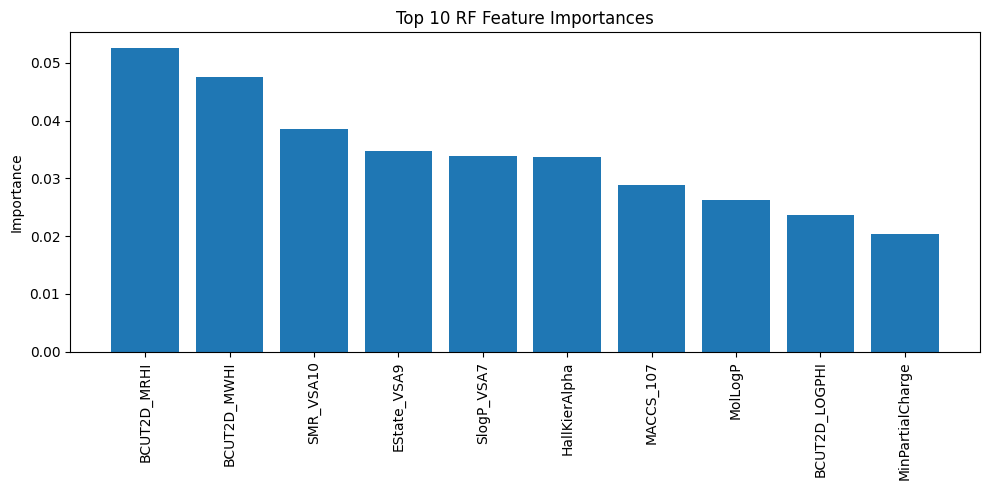

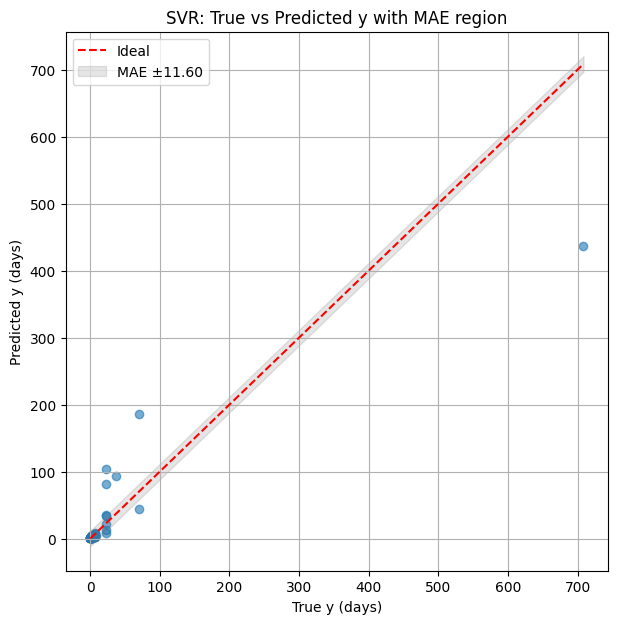

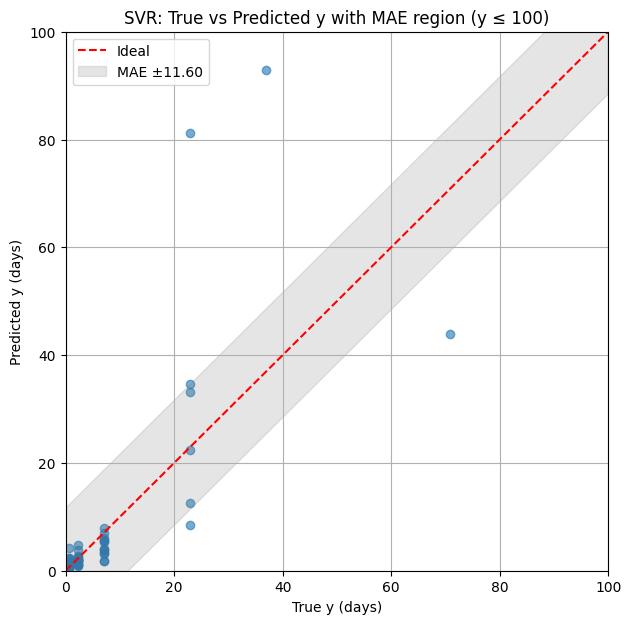

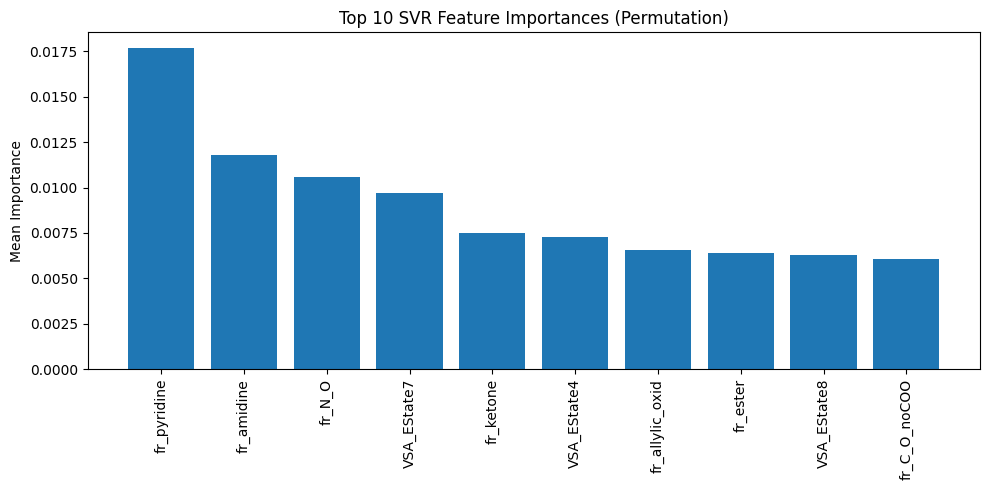

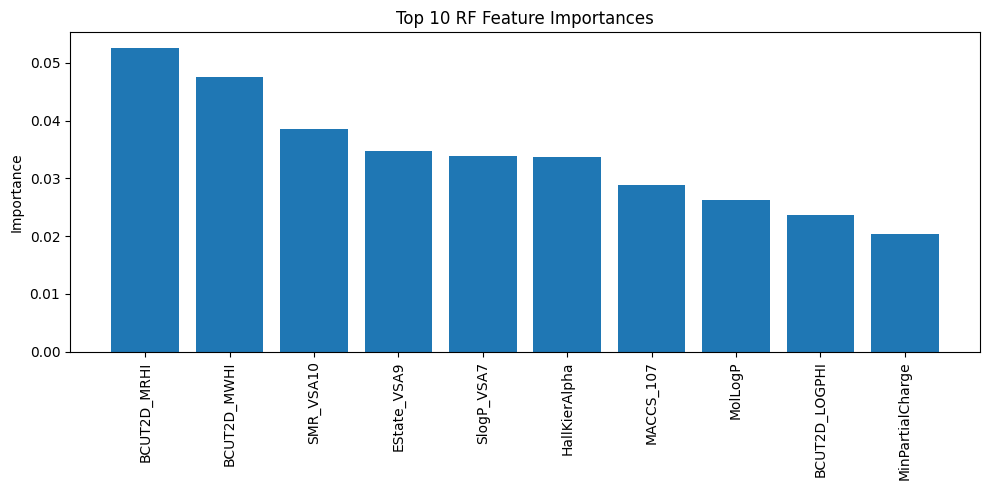

In [19]:
# Feature importance for Random Forest Regressor
importances_rf = best_rf.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1][:10]  # Top 10 features
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_rf[indices_rf])
plt.xticks(range(10), X_train.columns[indices_rf], rotation=90)
plt.title("Top 10 RF Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## SVR
looking best so far, at least for air_data

In [13]:
# Support Vector Regression (SVR) model
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.2, 0.5],
    "kernel": ["rbf", "linear", "poly"],
    "gamma": ["scale", "auto"],
}

svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_svr = grid_search.best_estimator_
# Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
# even with larger grid no improvement, same as before

Best parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


In [14]:
# svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)
svr = best_svr
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Inverse transform predictions and targets
y_test_exp_svr = np.power(10, y_test)
y_pred_exp_svr = np.power(10, y_pred_svr)
print("SVR metrics:")
output_metrics(y_test_exp_svr, y_pred_exp_svr)

SVR metrics:
R2: 0.795
MAE: 11.603
MSE: 1638.862
RMSE: 40.483
Explained Variance: 0.795


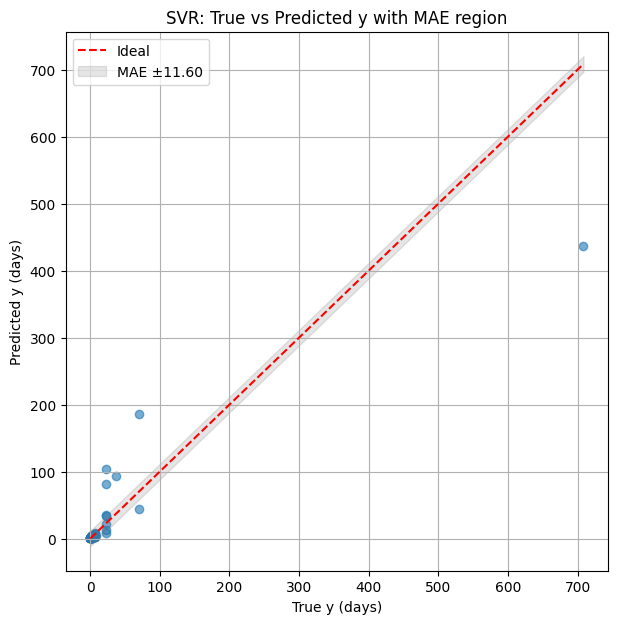

In [20]:
# SVR true vs predicted plot
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
plt.scatter(y_test_exp_svr, y_pred_exp_svr, alpha=0.6)
plt.plot([min(y_test_exp_svr), max(y_test_exp_svr)], [min(y_test_exp_svr), max(y_test_exp_svr)], "r--", label="Ideal")
plt.fill_between(
    [min(y_test_exp_svr), max(y_test_exp_svr)],
    [min(y_test_exp_svr) + mae, max(y_test_exp_svr) + mae],
    [min(y_test_exp_svr) - mae, max(y_test_exp_svr) - mae],
    color="gray",
    alpha=0.2,
    label=f"MAE ±{mae:.2f}",
)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region")
plt.legend()
plt.grid(True)
plt.show()

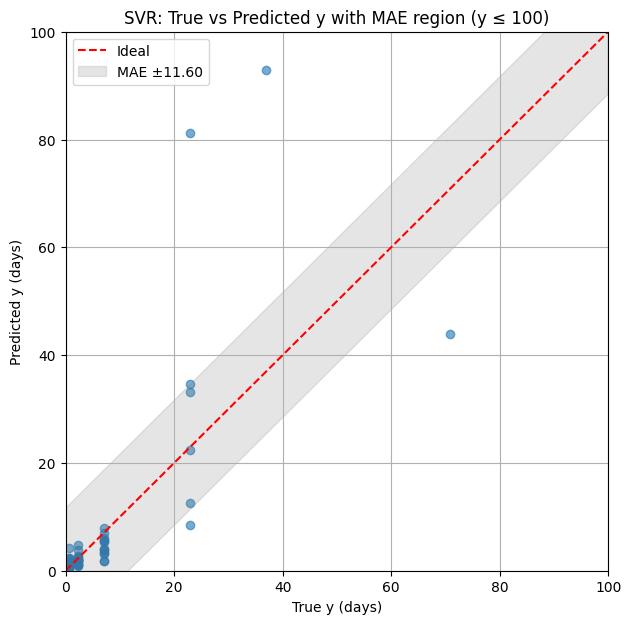

In [21]:
# Add shaded region for MAE to SVR true vs predicted plot, limited to x/y <= 100
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
# Only plot points where both true and predicted are <= 100
mask = (y_test_exp_svr <= 100) & (y_pred_exp_svr <= 100)
plt.scatter(y_test_exp_svr[mask], y_pred_exp_svr[mask], alpha=0.6)
plt.plot([0, 100], [0, 100], "r--", label="Ideal")
plt.fill_between([0, 100], [mae, 100 + mae], [-mae, 100 - mae], color="gray", alpha=0.2, label=f"MAE ±{mae:.2f}")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region (y ≤ 100)")
plt.legend()
plt.grid(True)
plt.show()

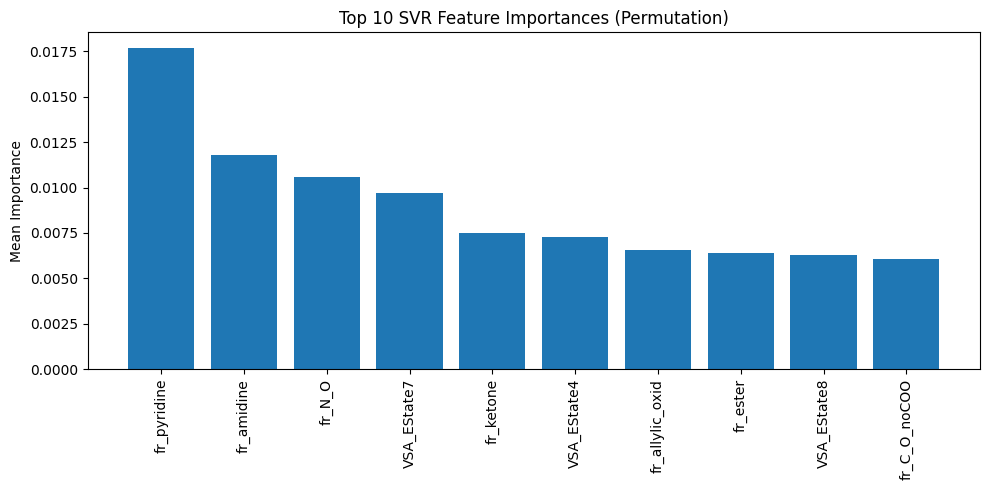

In [22]:
# Plot top ten features by permutation importance for SVR
from sklearn.inspection import permutation_importance

result = permutation_importance(svr, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_squared_error")
importances = result.importances_mean
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), X_test.columns[indices], rotation=90)
plt.title("Top 10 SVR Feature Importances (Permutation)")
plt.ylabel("Mean Importance")
plt.tight_layout()
plt.show()